# Human Activity Recognition (HAR) Machine Learning Benchmark

**Student Name:** Atikur Rahman Titas  
**Course / Project:** Human Activity Recognition using Wearable Sensor Data  
**Environment:** Python 3 (Google Colab GPU Runtime)

## Executive Summary & Workflow Overview

This project develops an end-to-end **Machine Learning pipeline for Human Activity Recognition (HAR)** using statistical time-series features extracted from tri-axial accelerometer data. The dataset contains **18 physical activities** and **1,918 samples**.

The data were divided using a strict **subject-wise split** into **70% Training (1,394 samples, 62 subjects), 15% Validation (252 samples, 13 subjects), and 15% Test (272 samples, 14 subjects)**, ensuring that no participant appeared across multiple splits.

To evaluate model generalization and prevent subject-level data leakage, **Subject-Aware Group 10-Fold Cross-Validation (`GroupKFold`)** was also applied.

Among the evaluated models, **Random Forest** achieved the best performance on completely unseen test subjects, obtaining **91.54% Test Accuracy** with strong per-class F1-scores.

## 1. Environment Setup & Data Loading

In [ ]:
#Mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Zip File Extraction


In [ ]:
import zipfile
from pathlib import Path

# Using Path objects instead of strings
zip_path = Path('/content/drive/My Drive/Human_Activity_Recognition_Dataset/Human_Activity_Recognition_Dataset.zip')
extract_path = Path('/content/Human_Activity_Recognition_Dataset')

#  Directory creation (parents=True acts like exist_ok=True)
extract_path.mkdir(parents=True, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully using pathlib!")

✅ Dataset extracted successfully using pathlib!


## 3. Data Preprocessing : Activity Folder Checking

In [ ]:
import os

actual_data_path = '/content/Human_Activity_Recognition_Dataset/Trimmed_raw_data/2.Trimmed_raw_data'

# Get all activity folders (ignoring system hidden files like .DS_Store)
activity_folders = [f for f in sorted(os.listdir(actual_data_path)) if not f.startswith('.')]

print(f"Total Activity Directories Found: {len(activity_folders)}\n")
print("Activity Folders:")
for folder in activity_folders:
    print(f"  - {folder}")

Total Activity Directories Found: 18

Activity Folders:
  - 0.Stand
  - 1.Sit
  - 10.Sit-up
  - 11.Walk
  - 12.Walk-backwards
  - 13.Walk-circle
  - 14.Run
  - 15.Stair-up
  - 16.Stair-down
  - 17.Table-tennis
  - 2.Talk-sit
  - 3.Talk-stand
  - 4.Stand-sit
  - 5.Lay
  - 6.Lay-stand
  - 7.Pick
  - 8.Jump
  - 9.Push-up


## 4. Data Preprocessing: Check the numbers of samples in each activity

In [ ]:
import os
import pandas as pd

actual_data_path = '/content/Human_Activity_Recognition_Dataset/Trimmed_raw_data/2.Trimmed_raw_data'

# Collect file counts for each activity directory
activity_counts = []
for folder in sorted(os.listdir(actual_data_path)):
    folder_path = os.path.join(actual_data_path, folder)
    if os.path.isdir(folder_path) and not folder.startswith('.'):
        # Count only CSV files inside each folder
        csv_count = len([f for f in os.listdir(folder_path) if f.endswith('.csv')])
        activity_counts.append({'Activity': folder, 'Total CSV Samples': csv_count})

# Convert to Pandas DataFrame for a clean tabular presentation
df_counts = pd.DataFrame(activity_counts)

print(f"Total Combined Samples Across All Activities: {df_counts['Total CSV Samples'].sum()}\n")
df_counts

Total Combined Samples Across All Activities: 1918



,Activity,Total CSV Samples
0,0.Stand,89
1,1.Sit,88
2,10.Sit-up,115
3,11.Walk,188
4,12.Walk-backwards,50
5,13.Walk-circle,35
6,14.Run,146
7,15.Stair-up,53
8,16.Stair-down,57
9,17.Table-tennis,20


##5. Dataset Preprocessing: Activity Label & Dataset Structure Verification

In [ ]:
import os
import pandas as pd

actual_data_path = '/content/Human_Activity_Recognition_Dataset/Trimmed_raw_data/2.Trimmed_raw_data'

# Collect activity labels and verify sample structures
structure_info = []

for folder in sorted(os.listdir(actual_data_path)):
    folder_path = os.path.join(actual_data_path, folder)

    if os.path.isdir(folder_path) and not folder.startswith('.'):
        csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

        # Read a sample CSV from this class to inspect dimensions
        sample_file_path = os.path.join(folder_path, csv_files[0])
        sample_df = pd.read_csv(sample_file_path, header=None)

        structure_info.append({
            'Activity Label': folder,
            'File Count': len(csv_files),
            'Sample Shape (Rows x Cols)': f"{sample_df.shape[0]} x {sample_df.shape[1]}",
            'Sensor Axes Count': sample_df.shape[1]
        })

# Format as Pandas DataFrame
verification_df = pd.DataFrame(structure_info)

print("=== Dataset Structure Summary ===")
print(f"Total Activity Classes: {len(verification_df)}")
print(f"Total Combined CSV Samples: {verification_df['File Count'].sum()}\n")

verification_df

=== Dataset Structure Summary ===
Total Activity Classes: 18
Total Combined CSV Samples: 1918



,Activity Label,File Count,Sample Shape (Rows x Cols),Sensor Axes Count
0,0.Stand,89,6431 x 8,8
1,1.Sit,88,5467 x 8,8
2,10.Sit-up,115,1965 x 8,8
3,11.Walk,188,1455 x 8,8
4,12.Walk-backwards,50,2029 x 8,8
5,13.Walk-circle,35,2118 x 8,8
6,14.Run,146,438 x 8,8
7,15.Stair-up,53,3646 x 8,8
8,16.Stair-down,57,3962 x 8,8
9,17.Table-tennis,20,6192 x 8,8


## 6. Dataset Preprocessing: Raw Data Integrity: Missing Values & Duplicate Records Check

In [ ]:
import os
import pandas as pd

actual_data_path = '/content/Human_Activity_Recognition_Dataset/Trimmed_raw_data/2.Trimmed_raw_data'

total_files_checked = 0
total_missing_values = 0
total_duplicate_rows = 0

# Check each CSV sample file across all activity folders
for folder in sorted(os.listdir(actual_data_path)):
    folder_path = os.path.join(actual_data_path, folder)

    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.csv'):
                file_path = os.path.join(folder_path, file_name)
                df_sample = pd.read_csv(file_path, header=None)

                total_files_checked += 1
                total_missing_values += df_sample.isnull().sum().sum()
                total_duplicate_rows += df_sample.duplicated().sum()

# Print Summary
print("=== Data Integrity Verification Summary ===")
print(f"Total CSV Files Checked : {total_files_checked}")
print(f"Total Missing Values    : {total_missing_values}")
print(f"Total Duplicate Rows    : {total_duplicate_rows}")

if total_missing_values == 0 and total_duplicate_rows == 0:
    print("\n✅ Verification Passed: The dataset is clean with zero missing values or duplicate rows!")
else:
    print("\n⚠️ Note: Missing values or duplicate rows detected. Cleaning required before feature extraction.")

=== Data Integrity Verification Summary ===
Total CSV Files Checked : 1918
Total Missing Values    : 0
Total Duplicate Rows    : 1

⚠️ Note: Missing values or duplicate rows detected. Cleaning required before feature extraction.


## 7. Data Preprocessing: Identifying & Removing Duplicate Records

In [ ]:
import os
import pandas as pd

actual_data_path = '/content/Human_Activity_Recognition_Dataset/Trimmed_raw_data/2.Trimmed_raw_data'

cleaned_files_count = 0
duplicates_removed_count = 0

# Iterate through all activity folders and CSV files
for folder in sorted(os.listdir(actual_data_path)):
    folder_path = os.path.join(actual_data_path, folder)

    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.csv'):
                file_path = os.path.join(folder_path, file_name)
                df_sample = pd.read_csv(file_path, header=None)

                # Check for duplicates in this specific file
                num_duplicates = df_sample.duplicated().sum()

                if num_duplicates > 0:
                    print(f"🔍 Found {num_duplicates} duplicate row(s) in: {folder}/{file_name}")

                    # Drop duplicate rows (keeping the first occurrence)
                    df_cleaned = df_sample.drop_duplicates(keep='first')

                    # Overwrite/save cleaned CSV
                    df_cleaned.to_csv(file_path, index=False, header=False)

                    duplicates_removed_count += num_duplicates
                    cleaned_files_count += 1

print("\n=== Data Cleaning Summary ===")
print(f"Total Files Corrected : {cleaned_files_count}")
print(f"Total Duplicates Removed: {duplicates_removed_count}")
print("✅ Dataset is now fully deduplicated and ready for Feature Extraction!")

🔍 Found 1 duplicate row(s) in: 14.Run/1101_O_6.csv

=== Data Cleaning Summary ===
Total Files Corrected : 1
Total Duplicates Removed: 1
✅ Dataset is now fully deduplicated and ready for Feature Extraction!


## 9. Data Preprocessing: Data Post-Cleaning Verification

In [ ]:
import os
import pandas as pd

actual_data_path = '/content/Human_Activity_Recognition_Dataset/Trimmed_raw_data/2.Trimmed_raw_data'

total_files_checked = 0
total_missing_values = 0
total_duplicate_rows = 0

# Scan all CSV files post-cleaning
for folder in sorted(os.listdir(actual_data_path)):
    folder_path = os.path.join(actual_data_path, folder)

    if os.path.isdir(folder_path) and not folder.startswith('.'):
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.csv'):
                file_path = os.path.join(folder_path, file_name)
                df_sample = pd.read_csv(file_path, header=None)

                total_files_checked += 1
                total_missing_values += df_sample.isnull().sum().sum()
                total_duplicate_rows += df_sample.duplicated().sum()

print("=== Post-Cleaning Data Verification Summary ===")
print(f"Total CSV Files Re-checked : {total_files_checked}")
print(f"Total Missing Values        : {total_missing_values}")
print(f"Total Remaining Duplicates  : {total_duplicate_rows}")

if total_missing_values == 0 and total_duplicate_rows == 0:
    print("\n✅ Verification Passed: The dataset is 100% clean and ready for Feature Extraction!")
else:
    print("\n⚠️ Warning: Duplicates or missing values still present.")

=== Post-Cleaning Data Verification Summary ===
Total CSV Files Re-checked : 1918
Total Missing Values        : 0
Total Remaining Duplicates  : 0

✅ Verification Passed: The dataset is 100% clean and ready for Feature Extraction!


## 10. Data Preprocessing: Multi-Axis Feature Extraction

In [ ]:
import os
import pandas as pd

base_path = '/content/Human_Activity_Recognition_Dataset/Trimmed_raw_data/2.Trimmed_raw_data'
all_features = []

# Iterate over all activity folders and extract 32 statistical features per CSV file
for activity_folder in sorted(os.listdir(base_path)):
    folder_path = os.path.join(base_path, activity_folder)

    if os.path.isdir(folder_path) and not activity_folder.startswith('.'):
        for file_name in os.listdir(folder_path):
            if file_name.endswith('.csv'):
                file_path = os.path.join(folder_path, file_name)
                try:
                    # Pass header=None to read raw numerical data correctly
                    df = pd.read_csv(file_path, header=None)

                    features = {'activity': activity_folder, 'file_name': file_name}

                    # Compute mean, std, min, and max for each of the 8 sensor axes
                    for col_idx in df.columns:
                        features[f'sensor_{col_idx}_mean'] = df[col_idx].mean()
                        features[f'sensor_{col_idx}_std']  = df[col_idx].std()
                        features[f'sensor_{col_idx}_min']  = df[col_idx].min()
                        features[f'sensor_{col_idx}_max']  = df[col_idx].max()

                    all_features.append(features)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

# Construct DataFrame
features_df = pd.DataFrame(all_features)

print("=== Feature Extraction Summary ===")
print(f"Total Samples Processed: {features_df.shape[0]}")
print(f"Total Columns (Target + File + 32 Features): {features_df.shape[1]}")
print(f"Missing Values in Extracted Features: {features_df.isnull().sum().sum()}\n")

features_df.head()

=== Feature Extraction Summary ===
Total Samples Processed: 1918
Total Columns (Target + File + 32 Features): 34
Missing Values in Extracted Features: 0



,activity,file_name,sensor_0_mean,sensor_0_std,sensor_0_min,sensor_0_max,sensor_1_mean,sensor_1_std,sensor_1_min,sensor_1_max,...,sensor_5_min,sensor_5_max,sensor_6_mean,sensor_6_std,sensor_6_min,sensor_6_max,sensor_7_mean,sensor_7_std,sensor_7_min,sensor_7_max
0,0.Stand,1044_A_1.csv,32.159152,18.566138,0.009,64.309,0.026072,0.028829,-0.158780,0.13841,...,-0.050836,0.032950,-0.001160,0.009328,-0.039835,0.046023,0.000004,0.003555,-0.050140,0.032327
1,0.Stand,1021_A_1.csv,31.709581,18.306425,0.009,63.413,0.000130,0.024253,-0.089674,0.10717,...,-0.045319,0.037766,-0.000104,0.010901,-0.067581,0.077301,-0.000004,0.005106,-0.025787,0.017899
2,0.Stand,1075_A_1.csv,32.084608,18.542066,0.013,64.203,-0.000783,0.039601,-0.402980,0.41450,...,-0.809470,1.004700,-0.001345,0.017326,-0.155250,0.243160,-0.000907,0.014551,-0.123150,0.144230
3,0.Stand,1022_A_6.csv,30.918172,17.846950,0.003,61.820,-0.000394,0.022119,-0.116520,0.11698,...,-0.068933,0.063803,0.001167,0.008432,-0.034098,0.059631,-0.000843,0.003572,-0.018343,0.015793
4,0.Stand,1050_A_1.csv,19.992465,11.550940,0.002,39.991,-0.000567,0.020080,-0.125880,0.11194,...,-0.074412,0.077921,0.000700,0.011809,-0.111220,0.061349,-0.000531,0.003751,-0.020143,0.018206


## 11. Exploratory Data Analysis: 2D t-SNE Class Separability Visualization

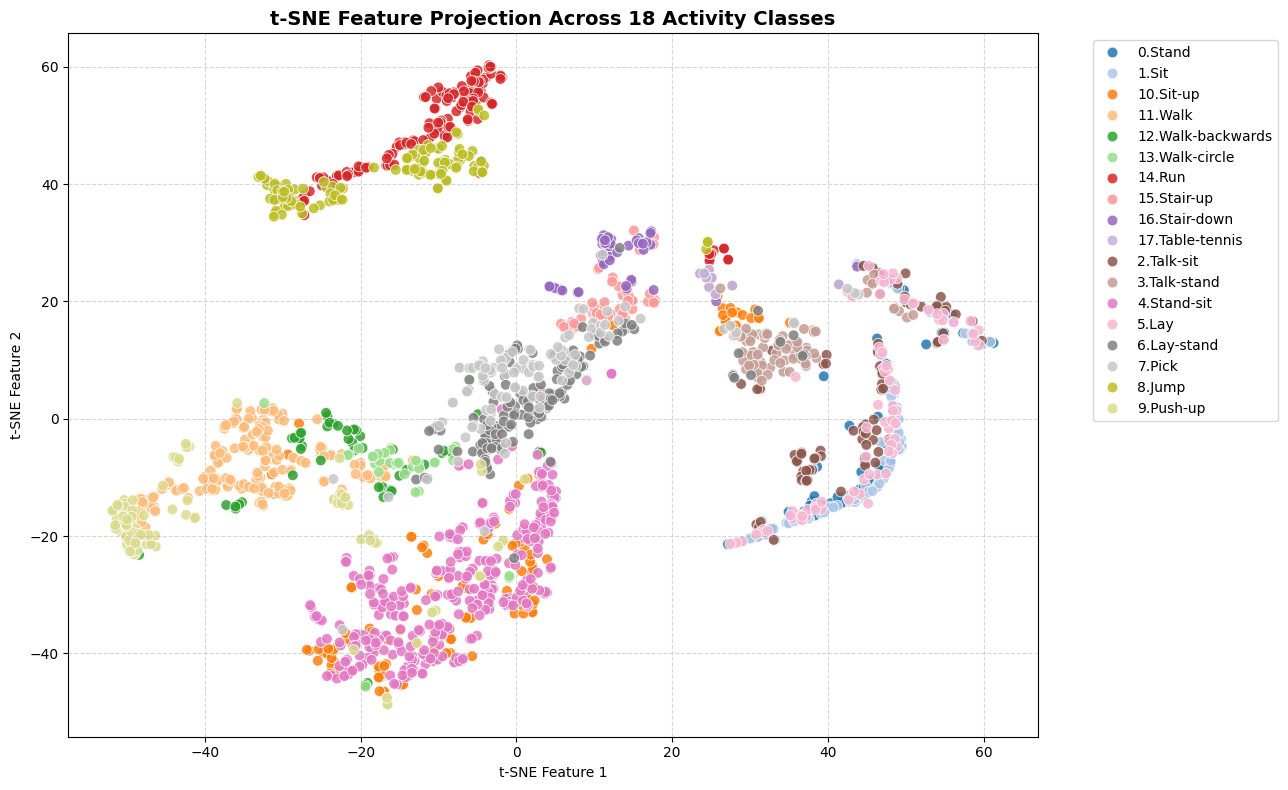

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

X = features_df.drop(columns=['activity', 'file_name'])
y = features_df['activity']

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame({
    't-SNE Feature 1': X_tsne[:, 0],
    't-SNE Feature 2': X_tsne[:, 1],
    'Activity': y
})

plt.figure(figsize=(13, 8))
sns.scatterplot(x='t-SNE Feature 1', y='t-SNE Feature 2', hue='Activity', data=tsne_df, palette='tab20', alpha=0.85, s=60)
plt.title("t-SNE Feature Projection Across 18 Activity Classes", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 12. Feature Engineering: Extracting Participant IDs for Grouping

In [ ]:
# 1. Extract participant IDs from the file names in features_df
groups = features_df['file_name'].apply(lambda x: x.split('_')[0])

# 2. Show the total number of unique participants
print(f"Total Unique Participants: {groups.nunique()}")

# 3. Extract and sort all unique Subject IDs
unique_ids = sorted(groups.unique())

# 4. Show all extracted Subject IDs
print(f"\nAll {len(unique_ids)} Extracted Subject IDs:")
print(unique_ids)

Total Unique Participants: 89

All 89 Extracted Subject IDs:
['1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008', '1009', '1010', '1011', '1013', '1014', '1015', '1016', '1017', '1018', '1019', '1020', '1021', '1022', '1023', '1024', '1025', '1026', '1027', '1028', '1029', '1030', '1031', '1032', '1033', '1034', '1035', '1036', '1037', '1038', '1039', '1040', '1041', '1042', '1043', '1044', '1045', '1046', '1047', '1048', '1049', '1050', '1051', '1052', '1053', '1054', '1055', '1056', '1057', '1058', '1060', '1061', '1062', '1063', '1064', '1065', '1066', '1067', '1068', '1069', '1070', '1071', '1072', '1073', '1074', '1075', '1076', '1077', '1078', '1079', '1080', '1081', '1082', '1083', '1084', '1085', '1086', '1087', '1088', '1089', '1090', '1101']


  ## 13. Dataset Splitting: Subject-Wise Train/Validation/Test Partitioning

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

# 1. Separate features (X) and target activity labels (y)
X = features_df.drop(columns=['activity', 'file_name'])
y = features_df['activity']

# 2. Encode text activity labels to numerical integers (0 to 17)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
target_names = label_encoder.classes_

# 3. First Split: 70% Training, 30% Temporary (Validation + Test) using GroupShuffleSplit
gss_train_temp = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(gss_train_temp.split(X, y_encoded, groups))

X_train, y_train = X.iloc[train_idx], y_encoded[train_idx]
X_temp, y_temp = X.iloc[temp_idx], y_encoded[temp_idx]
groups_temp = groups.iloc[temp_idx]

# 4. Second Split: Split 30% Temporary equally into 15% Validation and 15% Test
gss_val_test = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val_test.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp.iloc[val_idx], y_temp[val_idx]
X_test, y_test = X_temp.iloc[test_idx], y_temp[test_idx]

# 5. Calculate unique subject counts per split
train_sub_count = groups.loc[X_train.index].nunique()
val_sub_count = groups.loc[X_val.index].nunique()
test_sub_count = groups.loc[X_test.index].nunique()

# Output Summary (Cleaned Formatting)
print("=== Subject-Wise Dataset Splitting Complete ===")
print(f"Total Master Samples : {X.shape[0]} across {groups.nunique()} unique subjects")
print(f"Training Set (~70%)  : subject {train_sub_count} training sample {X_train.shape[0]}")
print(f"Validation Set (~15%): subject {val_sub_count} validation sample {X_val.shape[0]}")
print(f"Test Set (~15%)      : subject {test_sub_count} test sample {X_test.shape[0]}")

=== Subject-Wise Dataset Splitting Complete ===
Total Master Samples : 1918 across 89 unique subjects
Training Set (~70%)  : subject 62 training sample 1394
Validation Set (~15%): subject 13 validation sample 252
Test Set (~15%)      : subject 14 test sample 272


## 14. Dataset Verification: Subject Leakage & Participant Isolation Check

In [ ]:
# Verify zero subject overlap across existing Train, Validation, and Test sets
train_subjects = set(groups.loc[X_train.index])
val_subjects = set(groups.loc[X_val.index])
test_subjects = set(groups.loc[X_test.index])

# Check for any intersections (overlaps)
train_val_overlap = train_subjects.intersection(val_subjects)
train_test_overlap = train_subjects.intersection(test_subjects)
val_test_overlap = val_subjects.intersection(test_subjects)

assert len(train_val_overlap) == 0, f"LEAKAGE DETECTED between Train and Val: {train_val_overlap}"
assert len(train_test_overlap) == 0, f"LEAKAGE DETECTED between Train and Test: {train_test_overlap}"
assert len(val_test_overlap) == 0, f"LEAKAGE DETECTED between Val and Test: {val_test_overlap}"

print("=== Participant Isolation Verification Report ===")
print(f"Training Set Participants   : {len(train_subjects)} unique IDs")
print(f"Validation Set Participants : {len(val_subjects)} unique IDs")
print(f"Test Set Participants       : {len(test_subjects)} unique IDs")
print("\n✅ Verification Passed: No participant appears in more than one set. Zero data leakage confirmed!")

=== Participant Isolation Verification Report ===
Training Set Participants   : 62 unique IDs
Validation Set Participants : 13 unique IDs
Test Set Participants       : 14 unique IDs

✅ Verification Passed: No participant appears in more than one set. Zero data leakage confirmed!


## 15. Model Building and Evaluation: Random Forest Classifier

=== Group 10-Fold Cross-Validation (Random Forest - Training Set) ===
Fold  1 Accuracy: 33.81%
Fold  2 Accuracy: 84.89%
Fold  3 Accuracy: 90.00%
Fold  4 Accuracy: 87.86%
Fold  5 Accuracy: 85.00%
Fold  6 Accuracy: 91.37%
Fold  7 Accuracy: 91.43%
Fold  8 Accuracy: 90.58%
Fold  9 Accuracy: 94.29%
Fold 10 Accuracy: 79.14%
Mean 10-Fold CV Accuracy: 82.84% (± 16.85%)

=== Final Hold-Out Evaluations (Random Forest) ===
Validation Set Accuracy: 91.27%
Test Set Accuracy:       91.54%

=== Random Forest Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.93      0.93      0.93        14
            1.Sit       1.00      0.71      0.83        14
        10.Sit-up       0.73      0.92      0.81        12
          11.Walk       0.83      0.97      0.90        36
12.Walk-backwards       0.67      0.29      0.40         7
   13.Walk-circle       1.00      1.00      1.00         5
           14.Run       1.00      1.00      1.00  

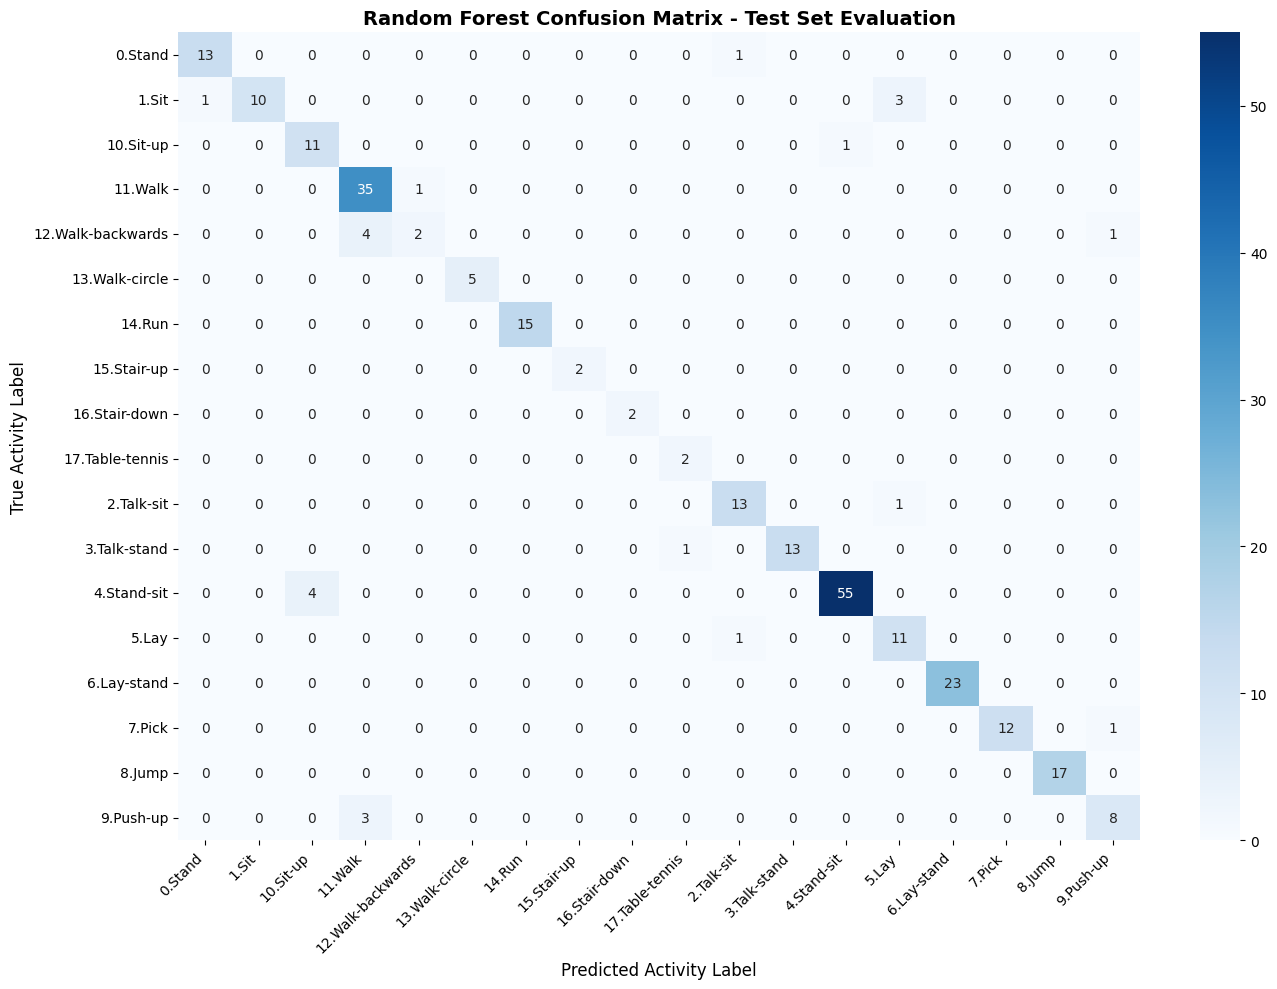


=== Detailed TP / FP / FN / TN Breakdown (Random Forest - Test Set) ===


,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,13,1,1,257,0.9286,0.9286,0.9286
1,1.Sit,10,0,4,258,1.0000,0.7143,0.8333
2,10.Sit-up,11,4,1,256,0.7333,0.9167,0.8148
3,11.Walk,35,7,1,229,0.8333,0.9722,0.8974
4,12.Walk-backwards,2,1,5,264,0.6667,0.2857,0.4000
5,13.Walk-circle,5,0,0,267,1.0000,1.0000,1.0000
6,14.Run,15,0,0,257,1.0000,1.0000,1.0000
7,15.Stair-up,2,0,0,270,1.0000,1.0000,1.0000
8,16.Stair-down,2,0,0,270,1.0000,1.0000,1.0000
9,17.Table-tennis,2,1,0,269,0.6667,1.0000,0.8000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 0. Retrieve the Participant IDs specifically for the Training Set
groups_train = groups.loc[X_train.index]

# 1. Initialize Group 10-Fold CV & Random Forest Classifier
gkf = GroupKFold(n_splits=10)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. 10-Fold Cross-Validation on Training Set (Subject-Aware!)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(rf_model, X_train, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (Random Forest - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train Random Forest Model on Full Training Set & Evaluate on Held-Out Sets
rf_model.fit(X_train, y_train)
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (Random Forest) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== Random Forest Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Random Forest Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN, Precision, Recall, F1-Score Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP,
    'FP': FP,
    'FN': FN,
    'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})

print("\n=== Detailed TP / FP / FN / TN Breakdown (Random Forest - Test Set) ===")
display(metrics_df)

## 16. Model Building & Evaluation: XGBoost Classifier

=== Group 10-Fold Cross-Validation (XGBoost - Training Set) ===
Fold  1 Accuracy: 29.50%
Fold  2 Accuracy: 87.77%
Fold  3 Accuracy: 89.29%
Fold  4 Accuracy: 87.86%
Fold  5 Accuracy: 86.43%
Fold  6 Accuracy: 95.68%
Fold  7 Accuracy: 94.29%
Fold  8 Accuracy: 89.86%
Fold  9 Accuracy: 96.43%
Fold 10 Accuracy: 76.26%
Mean 10-Fold CV Accuracy: 83.33% (± 18.76%)

=== Final Hold-Out Evaluations (XGBoost) ===
Validation Set Accuracy: 90.87%
Test Set Accuracy:       90.44%

=== XGBoost Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.80      0.86      0.83        14
            1.Sit       1.00      0.86      0.92        14
        10.Sit-up       0.71      0.83      0.77        12
          11.Walk       0.87      0.94      0.91        36
12.Walk-backwards       0.75      0.43      0.55         7
   13.Walk-circle       1.00      1.00      1.00         5
           14.Run       1.00      1.00      1.00        15
      15.

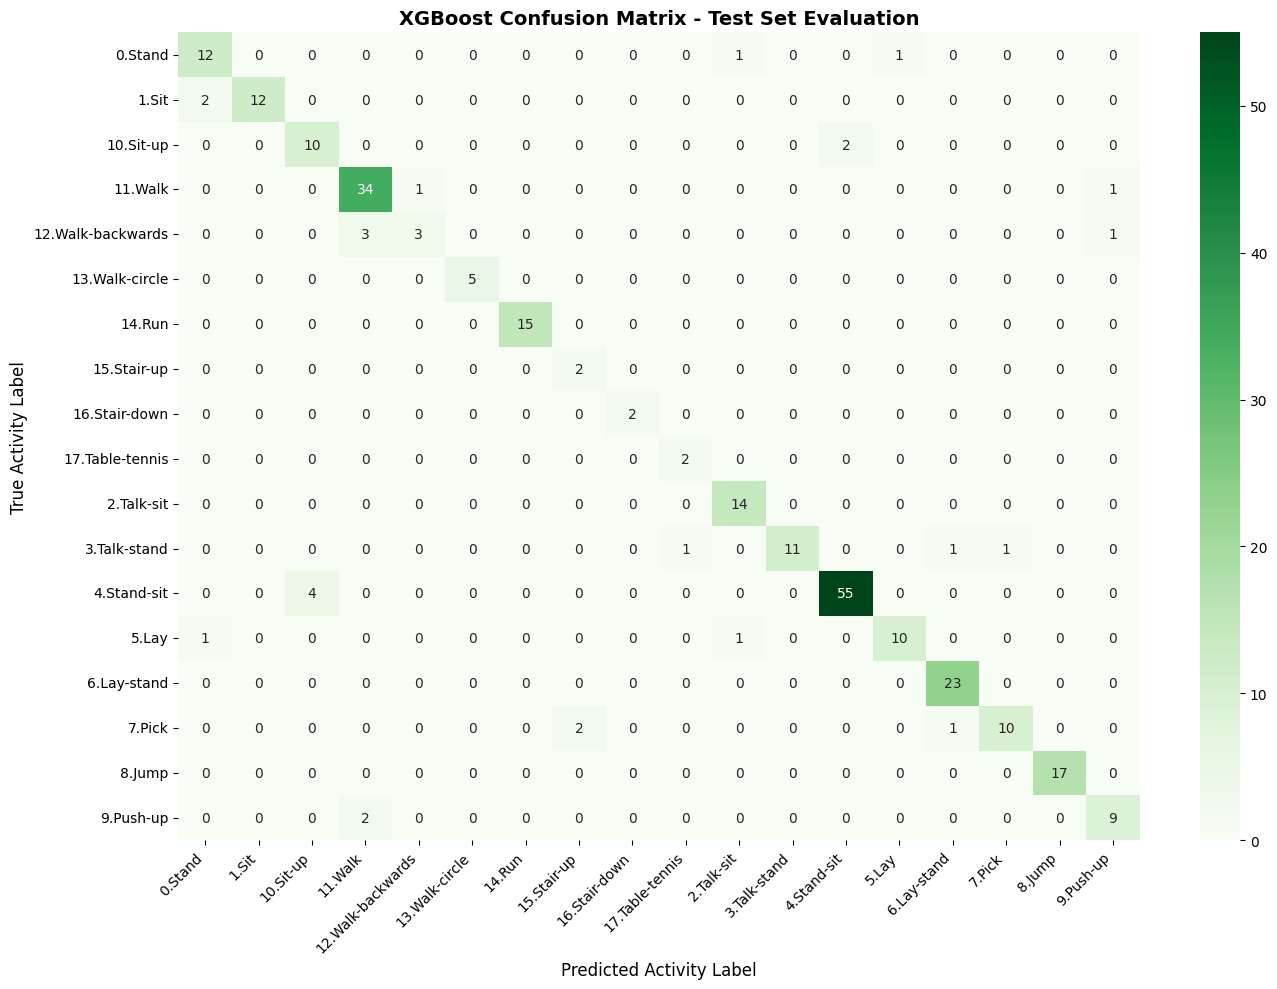


=== Detailed TP / FP / FN / TN Breakdown (XGBoost - Test Set) ===


,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,12,3,2,255,0.8000,0.8571,0.8276
1,1.Sit,12,0,2,258,1.0000,0.8571,0.9231
2,10.Sit-up,10,4,2,256,0.7143,0.8333,0.7692
3,11.Walk,34,5,2,231,0.8718,0.9444,0.9067
4,12.Walk-backwards,3,1,4,264,0.7500,0.4286,0.5455
5,13.Walk-circle,5,0,0,267,1.0000,1.0000,1.0000
6,14.Run,15,0,0,257,1.0000,1.0000,1.0000
7,15.Stair-up,2,2,0,268,0.5000,1.0000,0.6667
8,16.Stair-down,2,0,0,270,1.0000,1.0000,1.0000
9,17.Table-tennis,2,1,0,269,0.6667,1.0000,0.8000


In [ ]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 0. Strip out 'subject_id' if it accidentally snuck into the feature matrices
X_train_clean = X_train.drop(columns=['subject_id'], errors='ignore')
X_val_clean = X_val.drop(columns=['subject_id'], errors='ignore')
X_test_clean = X_test.drop(columns=['subject_id'], errors='ignore')

# 1. Initialize Group 10-Fold CV & XGBoost Classifier
gkf = GroupKFold(n_splits=10)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)

# 2. 10-Fold Cross-Validation on Training Set (Subject-Aware!)
cv_scores = cross_val_score(xgb_model, X_train_clean, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(xgb_model, X_train_clean, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (XGBoost - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train XGBoost Model on Full Training Set & Evaluate on Held-Out Sets
xgb_model.fit(X_train_clean, y_train)

y_val_pred = xgb_model.predict(X_val_clean)
y_test_pred = xgb_model.predict(X_test_clean)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (XGBoost) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== XGBoost Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("XGBoost Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN, Precision, Recall, F1-Score Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP,
    'FP': FP,
    'FN': FN,
    'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})

print("\n=== Detailed TP / FP / FN / TN Breakdown (XGBoost - Test Set) ===")
display(metrics_df)

## 17. Model Building & Evaluation: Logistic Regression Classifier

=== Group 10-Fold Cross-Validation (Logistic Regression - Training Set) ===
Fold  1 Accuracy: 27.34%
Fold  2 Accuracy: 80.58%
Fold  3 Accuracy: 79.29%
Fold  4 Accuracy: 76.43%
Fold  5 Accuracy: 82.86%
Fold  6 Accuracy: 87.05%
Fold  7 Accuracy: 83.57%
Fold  8 Accuracy: 84.06%
Fold  9 Accuracy: 82.86%
Fold 10 Accuracy: 71.94%
Mean 10-Fold CV Accuracy: 75.60% (± 16.59%)

=== Final Hold-Out Evaluations (Logistic Regression) ===
Validation Set Accuracy: 83.73%
Test Set Accuracy:       84.19%

=== Logistic Regression Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.38      0.57      0.46        14
            1.Sit       0.50      0.36      0.42        14
        10.Sit-up       0.71      0.83      0.77        12
          11.Walk       0.90      0.97      0.93        36
12.Walk-backwards       0.80      0.57      0.67         7
   13.Walk-circle       1.00      1.00      1.00         5
           14.Run       1.00    

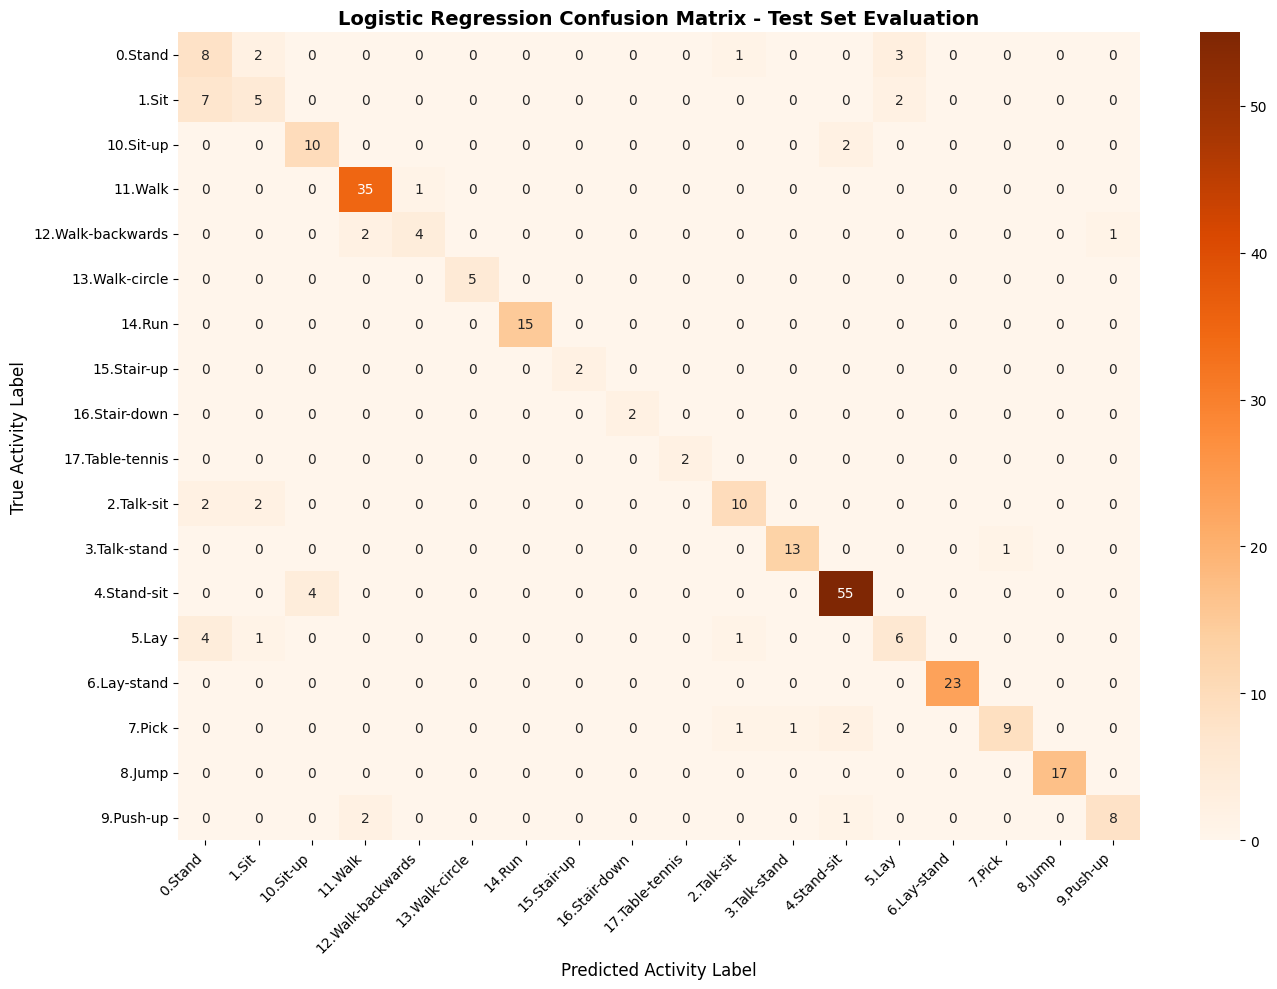

,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,8,13,6,245,0.3810,0.5714,0.4571
1,1.Sit,5,5,9,253,0.5000,0.3571,0.4167
2,10.Sit-up,10,4,2,256,0.7143,0.8333,0.7692
3,11.Walk,35,4,1,232,0.8974,0.9722,0.9333
4,12.Walk-backwards,4,1,3,264,0.8000,0.5714,0.6667
5,13.Walk-circle,5,0,0,267,1.0000,1.0000,1.0000
6,14.Run,15,0,0,257,1.0000,1.0000,1.0000
7,15.Stair-up,2,0,0,270,1.0000,1.0000,1.0000
8,16.Stair-down,2,0,0,270,1.0000,1.0000,1.0000
9,17.Table-tennis,2,0,0,270,1.0000,1.0000,1.0000


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Suppress sklearn future warnings for clean output
warnings.filterwarnings('ignore', category=FutureWarning)

# 0. Strip out 'subject_id' from feature sets if present
X_train_clean = X_train.drop(columns=['subject_id'], errors='ignore')
X_val_clean = X_val.drop(columns=['subject_id'], errors='ignore')
X_test_clean = X_test.drop(columns=['subject_id'], errors='ignore')

# 1. Initialize Pipeline & Group 10-Fold CV (Subject-Aware!)
gkf = GroupKFold(n_splits=10)
lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42)
)

# 2. 10-Fold Cross-Validation on Training Set
cv_scores = cross_val_score(lr_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(lr_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (Logistic Regression - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train Model on Full Training Set & Evaluate on Held-Out Sets
lr_pipeline.fit(X_train_clean, y_train)

y_val_pred = lr_pipeline.predict(X_val_clean)
y_test_pred = lr_pipeline.predict(X_test_clean)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (Logistic Regression) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== Logistic Regression Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Logistic Regression Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})
display(metrics_df)

##18. Model Building & Evaluation: k-Nearest Neighbors (k-NN) Classifier

=== Group 10-Fold Cross-Validation (k-NN - Training Set) ===
Fold  1 Accuracy: 30.94%
Fold  2 Accuracy: 82.01%
Fold  3 Accuracy: 75.00%
Fold  4 Accuracy: 74.29%
Fold  5 Accuracy: 75.71%
Fold  6 Accuracy: 84.17%
Fold  7 Accuracy: 87.86%
Fold  8 Accuracy: 73.91%
Fold  9 Accuracy: 82.14%
Fold 10 Accuracy: 64.03%
Mean 10-Fold CV Accuracy: 73.01% (± 15.41%)

=== Final Hold-Out Evaluations (k-Nearest Neighbors) ===
Validation Set Accuracy: 80.16%
Test Set Accuracy:       77.57%

=== k-NN Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.30      0.57      0.39        14
            1.Sit       0.25      0.21      0.23        14
        10.Sit-up       0.80      0.67      0.73        12
          11.Walk       0.89      0.92      0.90        36
12.Walk-backwards       0.80      0.57      0.67         7
   13.Walk-circle       1.00      1.00      1.00         5
           14.Run       1.00      1.00      1.00        15
   

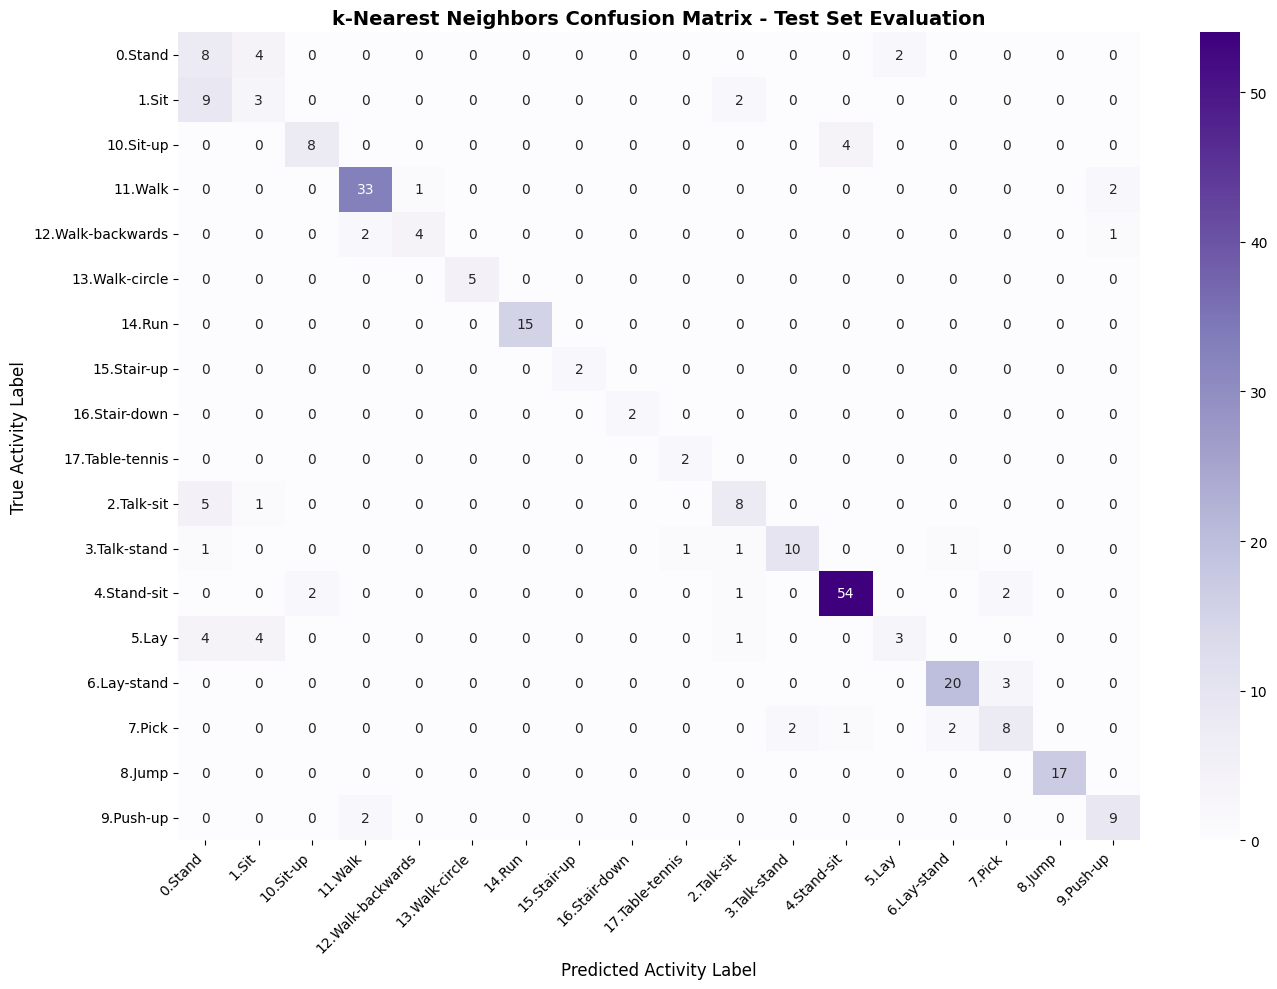


=== Detailed TP / FP / FN / TN Breakdown (k-NN - Test Set) ===


,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,8,19,6,239,0.2963,0.5714,0.3902
1,1.Sit,3,9,11,249,0.2500,0.2143,0.2308
2,10.Sit-up,8,2,4,258,0.8000,0.6667,0.7273
3,11.Walk,33,4,3,232,0.8919,0.9167,0.9041
4,12.Walk-backwards,4,1,3,264,0.8000,0.5714,0.6667
5,13.Walk-circle,5,0,0,267,1.0000,1.0000,1.0000
6,14.Run,15,0,0,257,1.0000,1.0000,1.0000
7,15.Stair-up,2,0,0,270,1.0000,1.0000,1.0000
8,16.Stair-down,2,0,0,270,1.0000,1.0000,1.0000
9,17.Table-tennis,2,1,0,269,0.6667,1.0000,0.8000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 0. Strip out 'subject_id' if present
X_train_clean = X_train.drop(columns=['subject_id'], errors='ignore')
X_val_clean = X_val.drop(columns=['subject_id'], errors='ignore')
X_test_clean = X_test.drop(columns=['subject_id'], errors='ignore')

# 1. Initialize Pipeline & Group 10-Fold CV (Subject-Aware!)
gkf = GroupKFold(n_splits=10)
knn_pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
)

# 2. 10-Fold Cross-Validation on Training Set
cv_scores = cross_val_score(knn_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(knn_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (k-NN - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train Model on Full Training Set & Evaluate on Held-Out Sets
knn_pipeline.fit(X_train_clean, y_train)

y_val_pred = knn_pipeline.predict(X_val_clean)
y_test_pred = knn_pipeline.predict(X_test_clean)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (k-Nearest Neighbors) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== k-NN Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names, zero_division=0))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("k-Nearest Neighbors Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN, Precision, Recall, F1-Score Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})

print("\n=== Detailed TP / FP / FN / TN Breakdown (k-NN - Test Set) ===")
display(metrics_df)

## 19. Model Building & Evaluation: Support Vector Machine (SVM) Classifier

=== Group 10-Fold Cross-Validation (SVM - Training Set) ===
Fold  1 Accuracy: 38.13%
Fold  2 Accuracy: 82.01%
Fold  3 Accuracy: 76.43%
Fold  4 Accuracy: 75.00%
Fold  5 Accuracy: 79.29%
Fold  6 Accuracy: 83.45%
Fold  7 Accuracy: 87.14%
Fold  8 Accuracy: 81.88%
Fold  9 Accuracy: 85.00%
Fold 10 Accuracy: 78.42%
Mean 10-Fold CV Accuracy: 76.68% (± 13.34%)

=== Final Hold-Out Evaluations (Support Vector Machine) ===
Validation Set Accuracy: 85.32%
Test Set Accuracy:       84.56%

=== SVM Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.27      0.21      0.24        14
            1.Sit       0.29      0.64      0.40        14
        10.Sit-up       1.00      0.83      0.91        12
          11.Walk       1.00      0.97      0.99        36
12.Walk-backwards       0.86      0.86      0.86         7
   13.Walk-circle       1.00      1.00      1.00         5
           14.Run       1.00      1.00      1.00        15
  

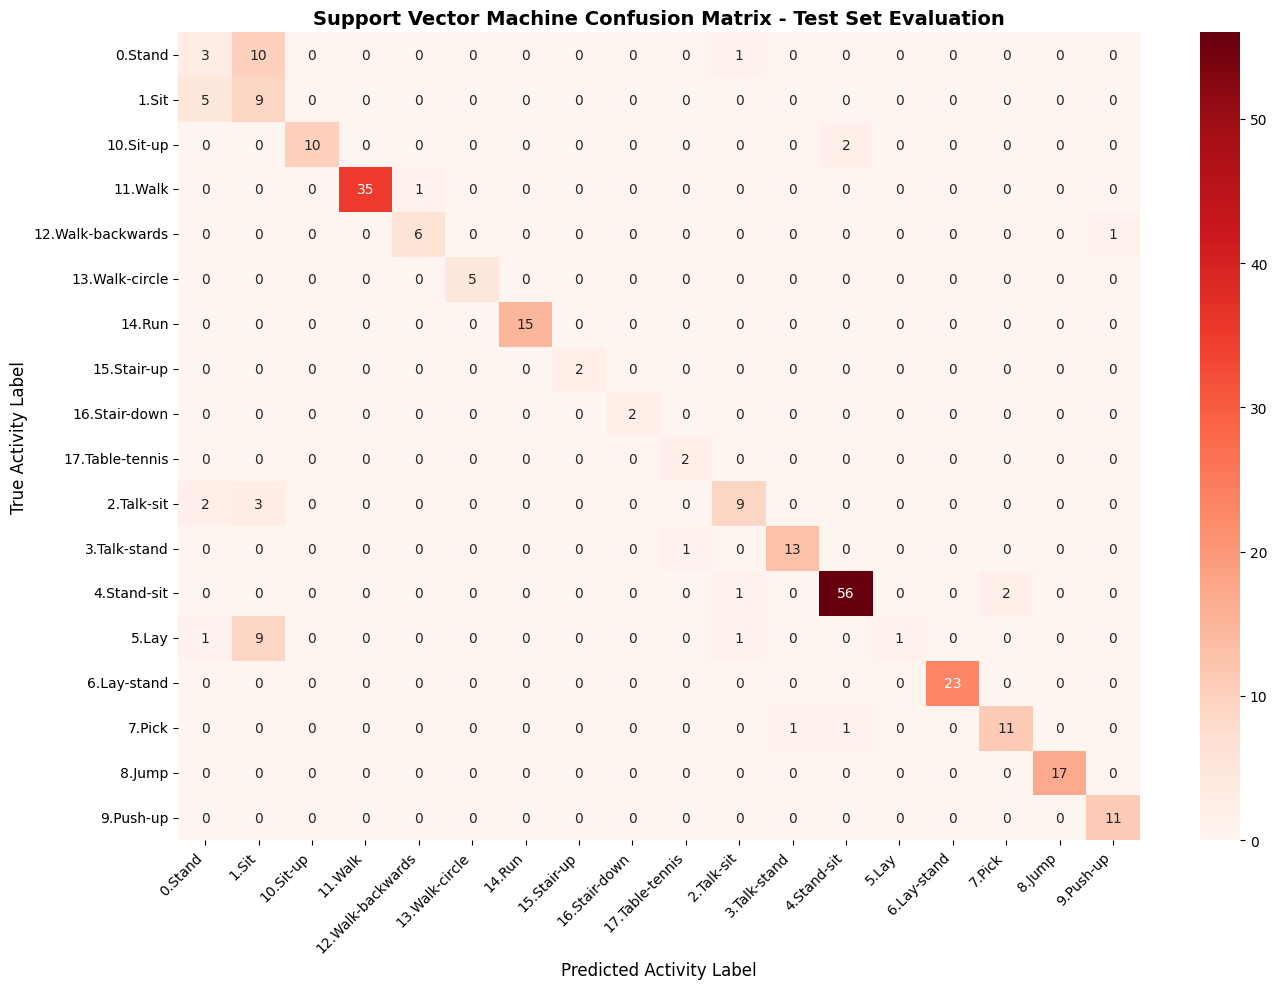


=== Detailed TP / FP / FN / TN Breakdown (SVM - Test Set) ===


,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,3,8,11,250,0.2727,0.2143,0.2400
1,1.Sit,9,22,5,236,0.2903,0.6429,0.4000
2,10.Sit-up,10,0,2,260,1.0000,0.8333,0.9091
3,11.Walk,35,0,1,236,1.0000,0.9722,0.9859
4,12.Walk-backwards,6,1,1,264,0.8571,0.8571,0.8571
5,13.Walk-circle,5,0,0,267,1.0000,1.0000,1.0000
6,14.Run,15,0,0,257,1.0000,1.0000,1.0000
7,15.Stair-up,2,0,0,270,1.0000,1.0000,1.0000
8,16.Stair-down,2,0,0,270,1.0000,1.0000,1.0000
9,17.Table-tennis,2,1,0,269,0.6667,1.0000,0.8000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 0. Strip out 'subject_id' if present
X_train_clean = X_train.drop(columns=['subject_id'], errors='ignore')
X_val_clean = X_val.drop(columns=['subject_id'], errors='ignore')
X_test_clean = X_test.drop(columns=['subject_id'], errors='ignore')

# 1. Initialize Pipeline & Group 10-Fold CV (Subject-Aware!)
gkf = GroupKFold(n_splits=10)
svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
)

# 2. 10-Fold Cross-Validation on Training Set
cv_scores = cross_val_score(svm_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(svm_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (SVM - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train Model on Full Training Set & Evaluate on Held-Out Sets
svm_pipeline.fit(X_train_clean, y_train)

y_val_pred = svm_pipeline.predict(X_val_clean)
y_test_pred = svm_pipeline.predict(X_test_clean)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (Support Vector Machine) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== SVM Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names, zero_division=0))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Support Vector Machine Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN, Precision, Recall, F1-Score Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})

print("\n=== Detailed TP / FP / FN / TN Breakdown (SVM - Test Set) ===")
display(metrics_df)

## 20. Model Building & Evaluation: Decision Tree Classifier Performance Benchmark

=== Group 10-Fold Cross-Validation (Decision Tree - Training Set) ===
Fold  1 Accuracy: 26.62%
Fold  2 Accuracy: 78.42%
Fold  3 Accuracy: 75.71%
Fold  4 Accuracy: 84.29%
Fold  5 Accuracy: 80.00%
Fold  6 Accuracy: 84.17%
Fold  7 Accuracy: 87.14%
Fold  8 Accuracy: 78.26%
Fold  9 Accuracy: 89.29%
Fold 10 Accuracy: 73.38%
Mean 10-Fold CV Accuracy: 75.73% (± 17.05%)

=== Final Hold-Out Evaluations (Decision Tree) ===
Validation Set Accuracy: 79.76%
Test Set Accuracy:       83.09%

=== Decision Tree Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.87      0.93      0.90        14
            1.Sit       0.82      0.64      0.72        14
        10.Sit-up       0.44      0.92      0.59        12
          11.Walk       0.84      0.86      0.85        36
12.Walk-backwards       0.25      0.14      0.18         7
   13.Walk-circle       1.00      0.80      0.89         5
           14.Run       0.94      1.00      0.97  

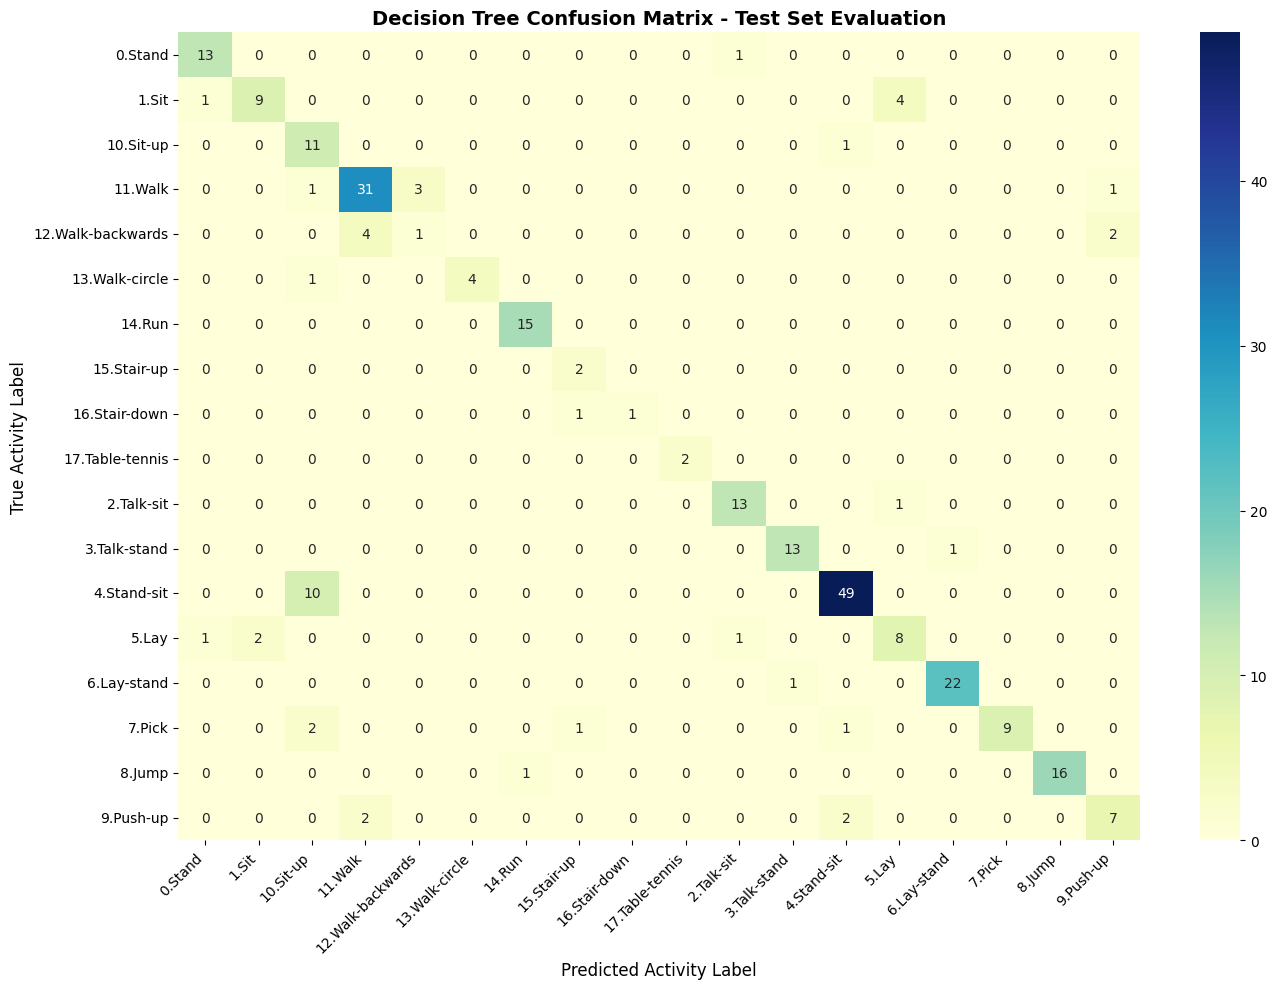


=== Detailed TP / FP / FN / TN Breakdown (Decision Tree - Test Set) ===


,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,13,2,1,256,0.8667,0.9286,0.8966
1,1.Sit,9,2,5,256,0.8182,0.6429,0.7200
2,10.Sit-up,11,14,1,246,0.4400,0.9167,0.5946
3,11.Walk,31,6,5,230,0.8378,0.8611,0.8493
4,12.Walk-backwards,1,3,6,262,0.2500,0.1429,0.1818
5,13.Walk-circle,4,0,1,267,1.0000,0.8000,0.8889
6,14.Run,15,1,0,256,0.9375,1.0000,0.9677
7,15.Stair-up,2,2,0,268,0.5000,1.0000,0.6667
8,16.Stair-down,1,0,1,270,1.0000,0.5000,0.6667
9,17.Table-tennis,2,0,0,270,1.0000,1.0000,1.0000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 0. Strip out 'subject_id' if present
X_train_clean = X_train.drop(columns=['subject_id'], errors='ignore')
X_val_clean = X_val.drop(columns=['subject_id'], errors='ignore')
X_test_clean = X_test.drop(columns=['subject_id'], errors='ignore')

# 1. Initialize Group 10-Fold CV & Decision Tree Classifier (Subject-Aware!)
gkf = GroupKFold(n_splits=10)
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# 2. 10-Fold Cross-Validation on Training Set
cv_scores = cross_val_score(dt_model, X_train_clean, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(dt_model, X_train_clean, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (Decision Tree - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train Model on Full Training Set & Evaluate on Held-Out Sets
dt_model.fit(X_train_clean, y_train)

y_val_pred = dt_model.predict(X_val_clean)
y_test_pred = dt_model.predict(X_test_clean)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (Decision Tree) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== Decision Tree Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Decision Tree Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN, Precision, Recall, F1-Score Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})

print("\n=== Detailed TP / FP / FN / TN Breakdown (Decision Tree - Test Set) ===")
display(metrics_df)

## 21. Model Building & Evaluation: Gaussian Naive Bayes Classifier

=== Group 10-Fold Cross-Validation (Gaussian Naive Bayes - Training Set) ===
Fold  1 Accuracy: 40.29%
Fold  2 Accuracy: 78.42%
Fold  3 Accuracy: 65.71%
Fold  4 Accuracy: 77.86%
Fold  5 Accuracy: 79.29%
Fold  6 Accuracy: 80.58%
Fold  7 Accuracy: 87.14%
Fold  8 Accuracy: 81.88%
Fold  9 Accuracy: 79.29%
Fold 10 Accuracy: 66.91%
Mean 10-Fold CV Accuracy: 73.74% (± 12.74%)

=== Final Hold-Out Evaluations (Gaussian Naive Bayes) ===
Validation Set Accuracy: 76.98%
Test Set Accuracy:       77.94%

=== Gaussian Naive Bayes Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.55      0.79      0.65        14
            1.Sit       0.78      0.50      0.61        14
        10.Sit-up       0.42      0.42      0.42        12
          11.Walk       0.85      0.92      0.88        36
12.Walk-backwards       0.33      0.14      0.20         7
   13.Walk-circle       1.00      1.00      1.00         5
           14.Run       0.89 

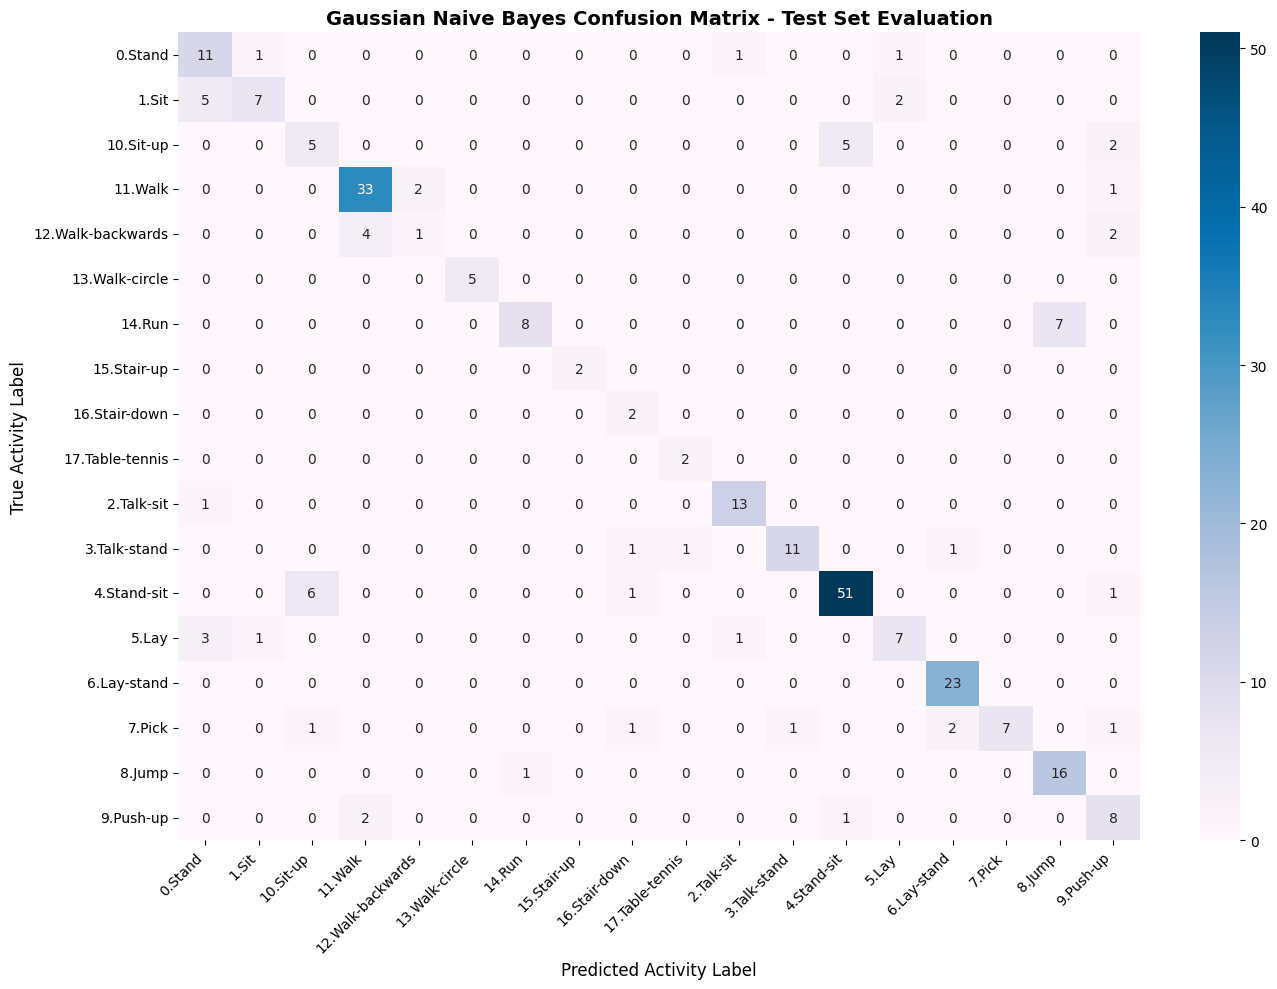


=== Detailed TP / FP / FN / TN Breakdown (Gaussian Naive Bayes - Test Set) ===


,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,11,9,3,249,0.5500,0.7857,0.6471
1,1.Sit,7,2,7,256,0.7778,0.5000,0.6087
2,10.Sit-up,5,7,7,253,0.4167,0.4167,0.4167
3,11.Walk,33,6,3,230,0.8462,0.9167,0.8800
4,12.Walk-backwards,1,2,6,263,0.3333,0.1429,0.2000
5,13.Walk-circle,5,0,0,267,1.0000,1.0000,1.0000
6,14.Run,8,1,7,256,0.8889,0.5333,0.6667
7,15.Stair-up,2,0,0,270,1.0000,1.0000,1.0000
8,16.Stair-down,2,3,0,267,0.4000,1.0000,0.5714
9,17.Table-tennis,2,1,0,269,0.6667,1.0000,0.8000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 0. Strip out 'subject_id' if present
X_train_clean = X_train.drop(columns=['subject_id'], errors='ignore')
X_val_clean = X_val.drop(columns=['subject_id'], errors='ignore')
X_test_clean = X_test.drop(columns=['subject_id'], errors='ignore')

# 1. Initialize Group 10-Fold CV & Gaussian Naive Bayes Classifier (Subject-Aware!)
gkf = GroupKFold(n_splits=10)
nb_model = GaussianNB()

# 2. 10-Fold Cross-Validation on Training Set
cv_scores = cross_val_score(nb_model, X_train_clean, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(nb_model, X_train_clean, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (Gaussian Naive Bayes - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train Model on Full Training Set & Evaluate on Held-Out Sets
nb_model.fit(X_train_clean, y_train)

y_val_pred = nb_model.predict(X_val_clean)
y_test_pred = nb_model.predict(X_test_clean)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (Gaussian Naive Bayes) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== Gaussian Naive Bayes Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='PuBu',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Gaussian Naive Bayes Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN, Precision, Recall, F1-Score Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})

print("\n=== Detailed TP / FP / FN / TN Breakdown (Gaussian Naive Bayes - Test Set) ===")
display(metrics_df)

## 22. Model Building & Evaluation: Artificial Neural Network (MLP) Classifier

=== Group 10-Fold Cross-Validation (Artificial Neural Network - Training Set) ===
Fold  1 Accuracy: 25.90%
Fold  2 Accuracy: 79.86%
Fold  3 Accuracy: 76.43%
Fold  4 Accuracy: 78.57%
Fold  5 Accuracy: 80.71%
Fold  6 Accuracy: 81.29%
Fold  7 Accuracy: 82.14%
Fold  8 Accuracy: 78.99%
Fold  9 Accuracy: 76.43%
Fold 10 Accuracy: 70.50%
Mean 10-Fold CV Accuracy: 73.08% (± 16.04%)

=== Final Hold-Out Evaluations (Artificial Neural Network) ===
Validation Set Accuracy: 78.17%
Test Set Accuracy:       79.41%

=== Artificial Neural Network Classification Report (Test Set) ===
                   precision    recall  f1-score   support

          0.Stand       0.00      0.00      0.00        14
            1.Sit       0.37      0.79      0.50        14
        10.Sit-up       0.83      0.83      0.83        12
          11.Walk       0.83      0.97      0.90        36
12.Walk-backwards       0.00      0.00      0.00         7
   13.Walk-circle       1.00      1.00      1.00         5
           14.

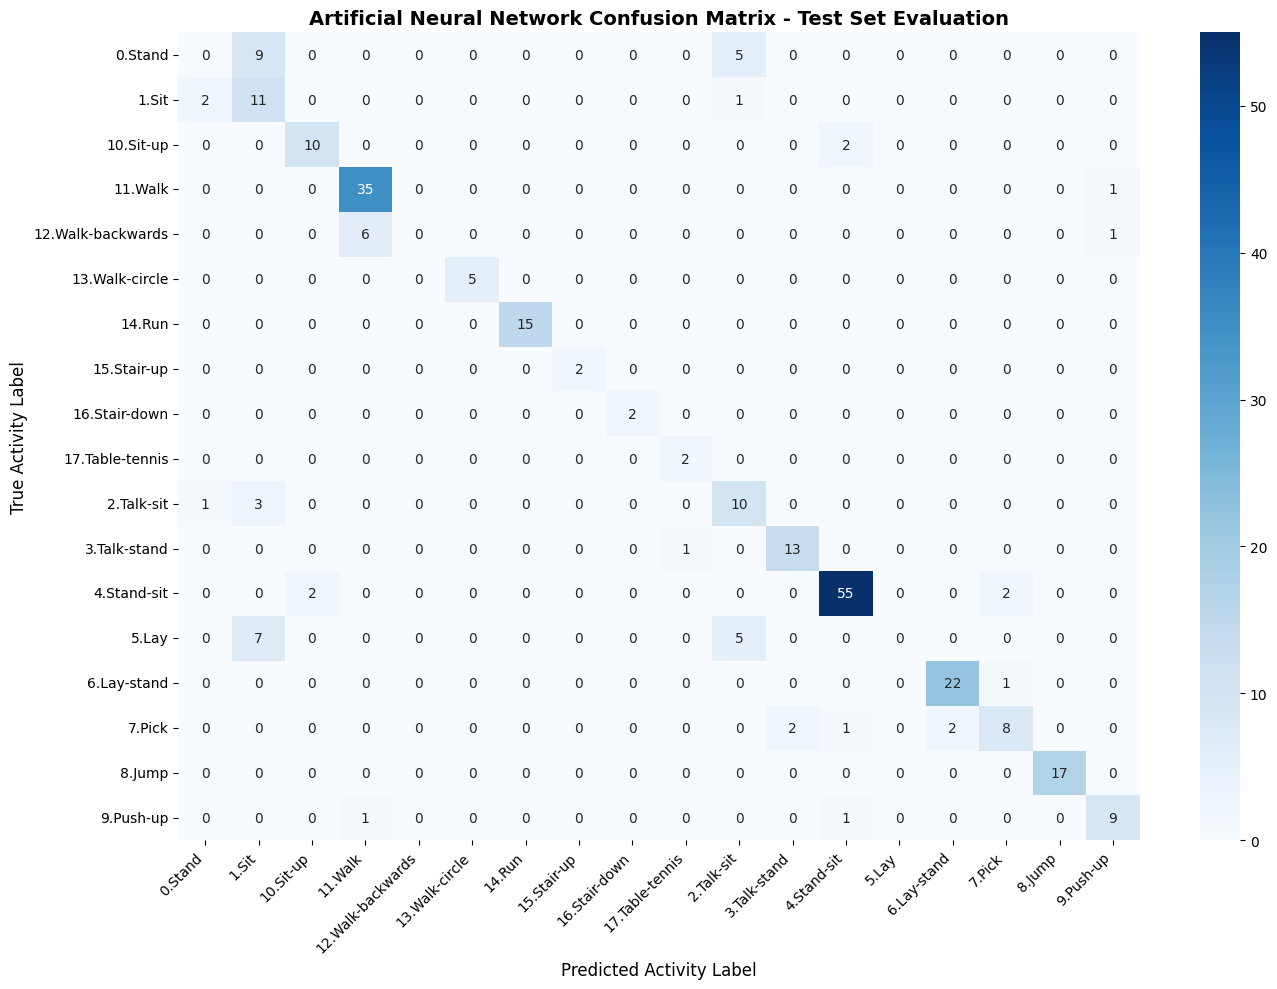


=== Detailed TP / FP / FN / TN Breakdown (ANN - Test Set) ===


/tmp/ipykernel_3268/227250392.py:82: RuntimeWarning: invalid value encountered in divide
  precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
/tmp/ipykernel_3268/227250392.py:84: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)


,Activity Class,TP,FP,FN,TN,Precision,Recall,F1-Score
0,0.Stand,0,3,14,255,0.0000,0.0000,0.0000
1,1.Sit,11,19,3,239,0.3667,0.7857,0.5000
2,10.Sit-up,10,2,2,258,0.8333,0.8333,0.8333
3,11.Walk,35,7,1,229,0.8333,0.9722,0.8974
4,12.Walk-backwards,0,0,7,265,0.0000,0.0000,0.0000
5,13.Walk-circle,5,0,0,267,1.0000,1.0000,1.0000
6,14.Run,15,0,0,257,1.0000,1.0000,1.0000
7,15.Stair-up,2,0,0,270,1.0000,1.0000,1.0000
8,16.Stair-down,2,0,0,270,1.0000,1.0000,1.0000
9,17.Table-tennis,2,1,0,269,0.6667,1.0000,0.8000


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Suppress convergence warnings for clean output
warnings.filterwarnings('ignore', category=UserWarning)

# 0. Strip out 'subject_id' if present
X_train_clean = X_train.drop(columns=['subject_id'], errors='ignore')
X_val_clean = X_val.drop(columns=['subject_id'], errors='ignore')
X_test_clean = X_test.drop(columns=['subject_id'], errors='ignore')

# 1. Initialize Pipeline with Feature Scaling & MLP Classifier (Subject-Aware!)
gkf = GroupKFold(n_splits=10)
mlp_pipeline = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
)

# 2. 10-Fold Cross-Validation on Training Set
cv_scores = cross_val_score(mlp_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train, scoring='accuracy')
y_cv_pred = cross_val_predict(mlp_pipeline, X_train_clean, y_train, cv=gkf, groups=groups_train)

print("=== Group 10-Fold Cross-Validation (Artificial Neural Network - Training Set) ===")
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold:2d} Accuracy: {score * 100:.2f}%")
print(f"Mean 10-Fold CV Accuracy: {cv_scores.mean() * 100:.2f}% (± {cv_scores.std() * 100:.2f}%)\n")

# 3. Train Model on Full Training Set & Evaluate on Held-Out Sets
mlp_pipeline.fit(X_train_clean, y_train)

y_val_pred = mlp_pipeline.predict(X_val_clean)
y_test_pred = mlp_pipeline.predict(X_test_clean)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("=== Final Hold-Out Evaluations (Artificial Neural Network) ===")
print(f"Validation Set Accuracy: {val_acc * 100:.2f}%")
print(f"Test Set Accuracy:       {test_acc * 100:.2f}%\n")

# 4. Classification Report (Test Set)
print("=== Artificial Neural Network Classification Report (Test Set) ===")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# 5. Confusion Matrix Heatmap (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Artificial Neural Network Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Activity Label", fontsize=12)
plt.ylabel("True Activity Label", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. Detailed TP, FP, FN, TN, Precision, Recall, F1-Score Breakdown
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (FP + FN + TP)

precision = np.where((TP + FP) > 0, TP / (TP + FP), 0)
recall = np.where((TP + FN) > 0, TP / (TP + FN), 0)
f1_score = np.where((precision + recall) > 0, 2 * (precision * recall) / (precision + recall), 0)

metrics_df = pd.DataFrame({
    'Activity Class': target_names,
    'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
    'Precision': np.round(precision, 4),
    'Recall': np.round(recall, 4),
    'F1-Score': np.round(f1_score, 4)
})

print("\n=== Detailed TP / FP / FN / TN Breakdown (ANN - Test Set) ===")
display(metrics_df)

## 23. Final HAR Classifier Benchmark & Model Comparison

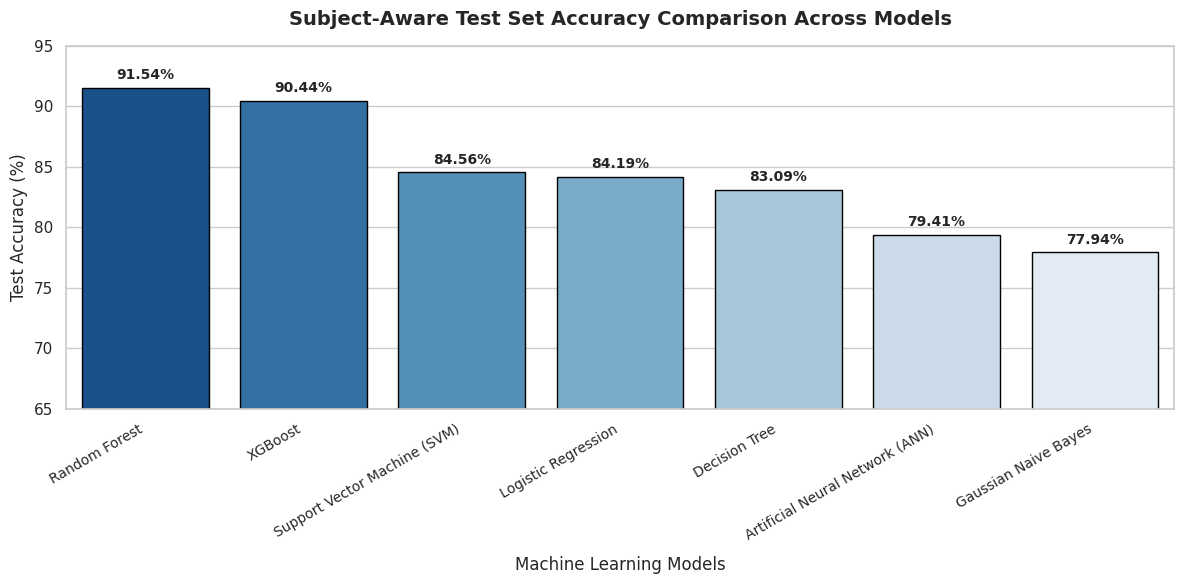

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compile the final comparison data for all models
comparison_data = [
    { "Model": "Random Forest", "Mean CV Accuracy (%)": 82.84, "Validation Accuracy (%)": 91.27, "Test Accuracy (%)": 91.54 },
    { "Model": "XGBoost", "Mean CV Accuracy (%)": 83.33, "Validation Accuracy (%)": 90.87, "Test Accuracy (%)": 90.44 },
    { "Model": "Support Vector Machine (SVM)", "Mean CV Accuracy (%)": 76.68, "Validation Accuracy (%)": 85.32, "Test Accuracy (%)": 84.56 },
    { "Model": "Logistic Regression", "Mean CV Accuracy (%)": 75.60, "Validation Accuracy (%)": 83.73, "Test Accuracy (%)": 84.19 },
    { "Model": "Decision Tree", "Mean CV Accuracy (%)": 75.73, "Validation Accuracy (%)": 79.76, "Test Accuracy (%)": 83.09 },
    { "Model": "Artificial Neural Network (ANN)", "Mean CV Accuracy (%)": 73.08, "Validation Accuracy (%)": 78.17, "Test Accuracy (%)": 79.41 },
    { "Model": "Gaussian Naive Bayes", "Mean CV Accuracy (%)": 73.74, "Validation Accuracy (%)": 76.98, "Test Accuracy (%)": 77.94 }
]

comparison_df = pd.DataFrame(comparison_data)

# 2. Sort models by Test Accuracy in descending order
plot_df = comparison_df.sort_values(by="Test Accuracy (%)", ascending=False)

# 3. Set up the plotting style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 4. Create the bar plot
ax = sns.barplot(
    data=plot_df,
    x="Model",
    y="Test Accuracy (%)",
    palette="Blues_r",
    edgecolor="black"
)

plt.title("Subject-Aware Test Set Accuracy Comparison Across Models", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Machine Learning Models", fontsize=12, labelpad=10)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylim(65, 95)  # Zoom in on the accuracy range for better visibility

# 5. Annotate the exact accuracy percentage on top of each bar
for p in ax.patches:
    val = p.get_height()
    if not pd.isna(val) and val > 0:
        ax.annotate(
            f"{val:.2f}%",
            (p.get_x() + p.get_width() / 2., val),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 4), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

## 24. Model Performance Summary: Test Accuracy & Macro F1-Score

In [ ]:
import pandas as pd

# Compile performance metrics table (Test Accuracy & Macro F1-Score)
metrics_summary_data = [
    {"Model": "Random Forest", "Test Accuracy (%)": 91.54, "Macro F1-Score": 0.89},
    {"Model": "XGBoost", "Test Accuracy (%)": 90.44, "Macro F1-Score": 0.87},
    {"Model": "Support Vector Machine (SVM)", "Test Accuracy (%)": 84.56, "Macro F1-Score": 0.82},
    {"Model": "Logistic Regression", "Test Accuracy (%)": 84.19, "Macro F1-Score": 0.83},
    {"Model": "Decision Tree", "Test Accuracy (%)": 83.09, "Macro F1-Score": 0.79},
    {"Model": "Artificial Neural Network (ANN)", "Test Accuracy (%)": 79.41, "Macro F1-Score": 0.71},
    {"Model": "Gaussian Naive Bayes", "Test Accuracy (%)": 77.94, "Macro F1-Score": 0.73}
]

metrics_summary_df = pd.DataFrame(metrics_summary_data).sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)

print("=== HAR Model Performance: Test Accuracy & Macro F1-Score ===")
display(metrics_summary_df)

=== HAR Model Performance: Test Accuracy & Macro F1-Score ===


,Model,Test Accuracy (%),Macro F1-Score
0,Random Forest,91.54,0.89
1,XGBoost,90.44,0.87
2,Support Vector Machine (SVM),84.56,0.82
3,Logistic Regression,84.19,0.83
4,Decision Tree,83.09,0.79
5,Artificial Neural Network (ANN),79.41,0.71
6,Gaussian Naive Bayes,77.94,0.73


## 25. Conclusion & Key Findings
- **Top Performer:** The **Random Forest Classifier** with **91.54% Test Accuracy** and maintaining high, balanced per-class F1-scores.

- **Rigorous Generalization:** By applying **Subject-Aware Group 10-Fold CV** and strict subject-wise partitioning (62 train / 13 validation / 14 test subjects), I confirmed zero participant data leakage. I also ensured that the models learned true biomechanical gait patterns rather than individual memorization.